In [12]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score
from sklearn.model_selection import TimeSeriesSplit
import warnings
import matplotlib.pyplot as plt

In [13]:
# Ignore warnings from zero division in precision calculation
warnings.filterwarnings('ignore', category=UserWarning)
# Set pandas display options for Jupyter Notebook
pd.set_option('display.max_columns', None)

In [14]:
def load_data(filepath: str) -> pd.DataFrame:
    """Loads raw stock data and ensures chronological order."""
    df = pd.read_csv(filepath, parse_dates=['date'])
    df = df.sort_values('date').reset_index(drop=True)
    print(f"Loaded {len(df)} rows from {filepath}")
    return df

In [16]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Generates purely stationary financial features (percentages/ratios)."""

    # Drop rows with NaN values created by rolling windows
    df = df.dropna()

    # 1. Intra-day metrics (Normalized as percentages, not absolute dollars)
    df['Daily_Change_Pct'] = (df['close'] - df['open']) / df['open']
    df['Daily_Range_Pct'] = (df['high'] - df['low']) / df['low']

    # 2. Moving Averages (Calculated for internal math, NOT fed to model)
    df['SMA_10'] = df['close'].rolling(window=10).mean()
    df['SMA_50'] = df['close'].rolling(window=50).mean()

    # 3. Distance from Moving Averages (This is the crucial stationary fix!)
    df['Dist_SMA_10'] = (df['close'] - df['SMA_10']) / df['SMA_10']
    df['Dist_SMA_50'] = (df['close'] - df['SMA_50']) / df['SMA_50']

    # 4. Volume Metrics
    df['Vol_Avg_20'] = df['volume'].rolling(window=20).mean()
    df['Rel_Volume'] = df['volume'] / df['Vol_Avg_20']

    # 5. Momentum (Rolling returns)
    df['Return_5d'] = df['close'].pct_change(periods=5)
    df['Return_20d'] = df['close'].pct_change(periods=20)

    # 6. Create Target Variable (1 if tomorrow closes higher than today, else 0)
    df['Tomorrow_Close'] = df['close'].shift(-1)
    df['Target'] = (df['Tomorrow_Close'] > df['close']).astype(int)

    print(f"Rows remaining after calculating indicators: {len(df)}")
    print(df.head())

    return df

In [17]:
# Load and Process Data
FILE_PATH = './individual_stocks_5yr/AAP_data.csv'
print(f"Loading data from {FILE_PATH}...")
raw_data = load_data(FILE_PATH)
processed_data = engineer_features(raw_data.copy())
print(f"Rows remaining after calculating indicators: {len(processed_data)}\n")

Loading data from ./individual_stocks_5yr/AAP_data.csv...
Loaded 1259 rows from ./individual_stocks_5yr/AAP_data.csv
Rows remaining after calculating indicators: 1259
        date   open   high      low  close   volume Name  Daily_Change_Pct  \
0 2013-02-08  78.34  79.72  78.0100  78.90  1298137  AAP          0.007148   
1 2013-02-11  78.65  78.91  77.2300  78.39   758016  AAP         -0.003306   
2 2013-02-12  78.39  78.63  77.5132  78.60   876859  AAP          0.002679   
3 2013-02-13  78.90  79.13  77.8500  78.97  1038574  AAP          0.000887   
4 2013-02-14  78.66  79.72  78.5850  78.84  1005376  AAP          0.002288   

   Daily_Range_Pct  SMA_10  SMA_50  Dist_SMA_10  Dist_SMA_50  Vol_Avg_20  \
0         0.021920     NaN     NaN          NaN          NaN         NaN   
1         0.021753     NaN     NaN          NaN          NaN         NaN   
2         0.014408     NaN     NaN          NaN          NaN         NaN   
3         0.016442     NaN     NaN          NaN          NaN

In [18]:
# Define the EXACT features to use
# CRITICAL: We DO NOT include 'open', 'high', 'low', 'close', 'SMA_10', or 'SMA_50' here.
features = [
    'Daily_Change_Pct',
    'Daily_Range_Pct',
    'Dist_SMA_10',
    'Dist_SMA_50',
    'Rel_Volume',
    'Return_5d',
    'Return_20d'
]

X = processed_data[features]
y = processed_data['Target']

In [19]:
# Setup Time Series Cross-Validation
tscv = TimeSeriesSplit(n_splits=5)
precision_scores = []
accuracy_scores = []

print("--- Training and Evaluating over 5 Time Periods ---")

for fold, (train_index, test_index) in enumerate(tscv.split(X), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train model
    model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)

    # Predict and evaluate
    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions, zero_division=0)

    accuracy_scores.append(acc)
    precision_scores.append(prec)

    print(f"Fold {fold} - Accuracy: {acc*100:.2f}%, Precision: {prec*100:.2f}%")

print("\n--- Final Aggregated Results ---")
print(f"Average Accuracy:  {np.mean(accuracy_scores) * 100:.2f}%")
print(f"Average Precision: {np.mean(precision_scores) * 100:.2f}%")

--- Training and Evaluating over 5 Time Periods ---
Fold 1 - Accuracy: 48.33%, Precision: 48.62%
Fold 2 - Accuracy: 55.50%, Precision: 63.64%
Fold 3 - Accuracy: 52.63%, Precision: 50.71%
Fold 4 - Accuracy: 46.41%, Precision: 42.66%
Fold 5 - Accuracy: 44.02%, Precision: 43.43%

--- Final Aggregated Results ---
Average Accuracy:  49.38%
Average Precision: 49.81%


In [20]:
# Feature Importance Analysis
print("\nGenerating Feature Importances Plot...")
final_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
final_model.fit(X, y)

importances = pd.Series(final_model.feature_importances_, index=features).sort_values(ascending=True)


Generating Feature Importances Plot...


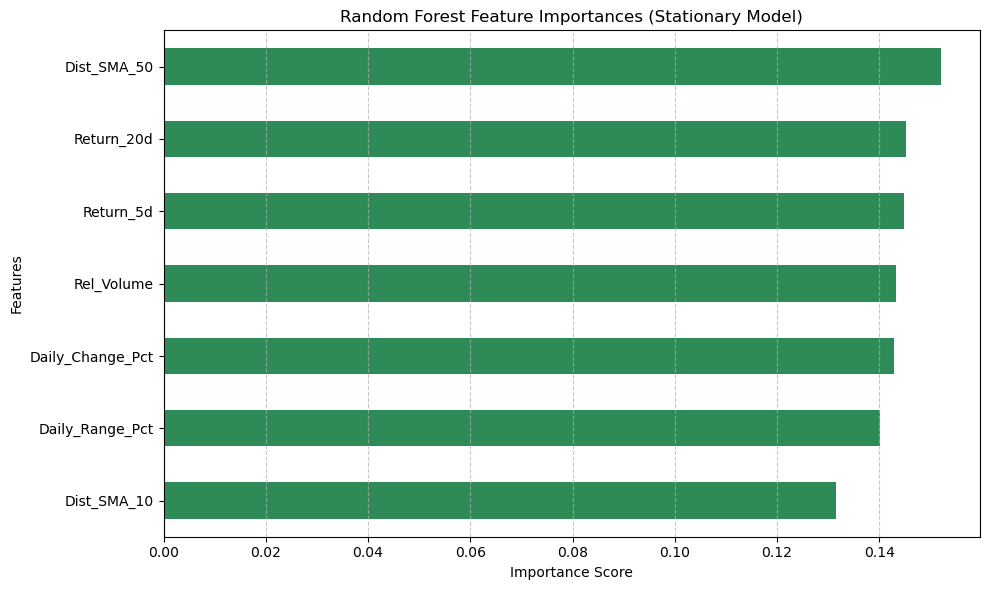

In [21]:
# Plotting the results
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='seagreen')
plt.title('Random Forest Feature Importances (Stationary Model)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()